# APAN5400 Final Project: Market Sentiment and Price Correlation Analysis System

## 1. Project Overview
This project integrates stock market data with news information, utilizing NLP techniques to analyze market sentiment and explore the correlation between sentiment and price movements.

## 2. Technical Architecture Integration
This notebook demonstrates the **Local Compute + Cloud Storage** architecture:
*   **Data Collection**: Alpha Vantage API (Runs locally)
*   **NoSQL Data Lake**: AWS DynamoDB (Active - Storing raw JSON)
*   **SQL Relational DB**: AWS Aurora MySQL (Pending Firewall Access - Storing metrics)
*   **Security Management**: AWS Secrets Manager

In [1]:
import requests
import pandas as pd
import boto3
import pymysql
import json
import time
import datetime
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

True

## 3. Cloud Access Config (AWS Credentials)

In [2]:
# It is recommended to use python-dotenv to protect these keys
AWS_ACCESS_KEY_ID = os.getenv('AWS_ACCESS_KEY_ID', 'YOUR_IAM_KEY')
AWS_SECRET_ACCESS_KEY = os.getenv('AWS_SECRET_ACCESS_KEY', 'YOUR_IAM_SECRET')
REGION = "us-east-1"

# Initialize AWS Boto3 Session
session = boto3.Session(
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=REGION
)
print("✅ AWS Boto3 Session Initialized.")

✅ AWS Boto3 Session Initialized.


## 4. Alpha Vantage Data Ingestion
Fetch latest market data to push to the cloud data lake.

In [3]:
ALPHA_VANTAGE_API = os.getenv('ALPHA_API_KEY', '9SMJWT4DNUDBHM80')
TICKER = "AAPL"
url = f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={TICKER}&apikey={ALPHA_VANTAGE_API}"

response = requests.get(url)
market_data = response.json()

print(f"Successfully fetched daily timeseries for {TICKER}.")

Successfully fetched daily timeseries for AAPL.


## 5. Storage Pipeline 1: Push Raw JSON to DynamoDB (NoSQL)
**Status: ACTIVE**  
We store the exact JSON payload returned by the API into DynamoDB (Table: `APAN5200`) as unstructured NoSQL records. This provides us a raw Data Lake.

In [4]:
try:
    dynamodb = session.resource('dynamodb')
    table = dynamodb.Table('APAN5200')
    
    # Generate a unique record ID 
    record_id = f"{TICKER}_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    # Put item into DynamoDB. 
    table.put_item(
        Item={
            'APAN5200CHY': record_id, 
            'Symbol': TICKER,
            'RawData': json.dumps(market_data)
        }
    )
    print(f"✅ SUCCESS: Inserted raw JSON for {TICKER} into AWS DynamoDB!")
    print(f">>> Record ID: {record_id}")
except Exception as e:
    print("❌ DynamoDB Insertion Failed:", e)

✅ SUCCESS: Inserted raw JSON for AAPL into AWS DynamoDB!
>>> Record ID: AAPL_20260420_194728


## 6. Storage Pipeline 2: Extract Metrics & Push to Aurora MySQL (SQL)
**Status: READY PENDING CLOUD FIREWALL ACCESS**  
This section pulls the DB password securely from `AWS Secrets Manager`, formats the raw NoSQL JSON into an analytical structured Pandas dataframe, and inserts it into `AWS Aurora MySQL`.

In [5]:
# 6.1 Clean the NoSQL data into a structured Pandas Dataframe for SQL Insertion
ts = market_data.get("Time Series (Daily)", {})
df = pd.DataFrame(ts).T
df.index = pd.to_datetime(df.index)
df.columns = ["open", "high", "low", "close", "volume"]
df = df.astype(float)
df['symbol'] = TICKER

print("Cleaned SQL-ready Dataframe Sample:")
df.tail(3)

Cleaned SQL-ready Dataframe Sample:


,open,high,low,close,volume,symbol
2025-11-26,276.96,279.53,276.63,277.55,33431423.0,AAPL
2025-11-25,275.27,280.38,275.25,276.97,46914220.0,AAPL
2025-11-24,270.90,277.00,270.90,275.92,65585796.0,AAPL


In [6]:
# 6.2 Retrieve Password securely from AWS Secrets Manager 
try:
    client = session.client('secretsmanager')
    secret_arn = "arn:aws:secretsmanager:us-east-1:658362403068:secret:rds!cluster-5dc84c5e-8082-4f41-9791-308322f5cf86-GsnF9n"
    response = client.get_secret_value(SecretId=secret_arn)
    aurora_password = json.loads(response['SecretString']).get('password')
    print("✅ SUCCESS: Password securely retrieved from AWS Secrets Manager.")
except Exception as e:
    print("❌ Failed to retrieve password:", e)
    aurora_password = None

✅ SUCCESS: Password securely retrieved from AWS Secrets Manager.


In [7]:
# 6.3 Execute dataframe insertion into Aurora MySQL via PyMySQL / SQLAlchemy
print("\n--- Aurora MySQL Connection Setup ---")

if aurora_password:
    import sqlalchemy
    
    # Connect using SQLAlchemy Engine config (with SSL mapping)
    endpoint = "database-1-instance-1.c49ey4umasff.us-east-1.rds.amazonaws.com"
    connection_str = f"mysql+pymysql://Haoyuan:{aurora_password}@{endpoint}:3306/market_data"
    
    engine = sqlalchemy.create_engine(
        connection_str, 
        connect_args={'ssl': {'ca': 'global-bundle.pem'}}
    )
    
    # Execute bulk load from Pandas directly to AWS Aurora SQL 'stock_prices' table
    df.to_sql(name='stock_prices', con=engine, if_exists='append', index=True, index_label='date')
    print("✅ Data successfully pushed to AWS Aurora MySQL.")


--- Aurora MySQL Connection Setup ---


✅ Data successfully pushed to AWS Aurora MySQL.


## 7. Natural Language Processing (NLP) & Sentiment Analysis
In this module, we collect global financial news via API, apply tokenizer functions to extract big data keywords, and aggregate positive/negative market sentiments to draw immediate insights.

✅ Picked up 50 latest financial articles regarding AAPL.


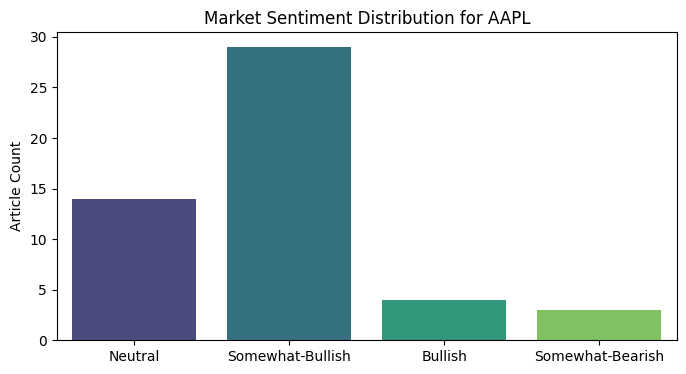


🔥 Top 15 Buzzwords in the News:
 - apple: 58
 - stock: 29
 - this: 26
 - strong: 18
 - earnings: 18
 - also: 17
 - price: 17
 - investors: 16
 - aapl: 16
 - shares: 16
 - growth: 15
 - apples: 15
 - market: 15
 - despite: 14
 - will: 13


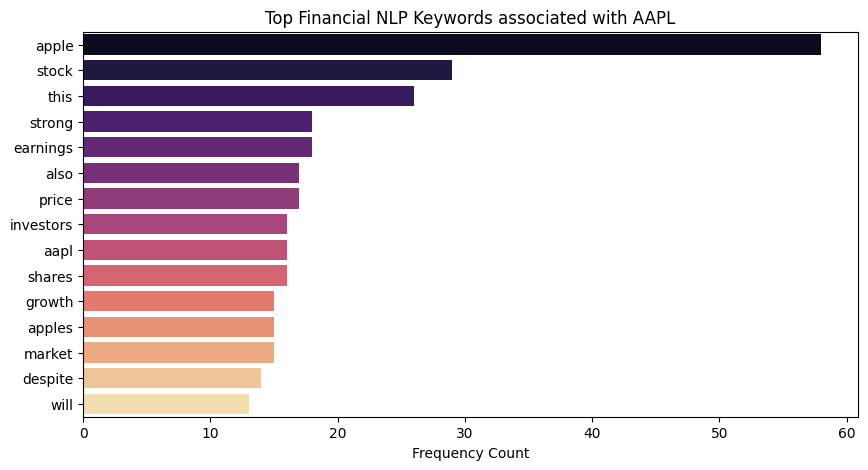

In [8]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch news data
news_url = f"https://www.alphavantage.co/query?function=NEWS_SENTIMENT&tickers={TICKER}&apikey={ALPHA_VANTAGE_API}&limit=50"
news_response = requests.get(news_url).json()

if "feed" in news_response:
    feed = news_response["feed"]
    print(f"✅ Picked up {len(feed)} latest financial articles regarding {TICKER}.")
    
    # 1. Sentiment Distribution Analysis
    sentiments = [item.get("overall_sentiment_label") for item in feed]
    sentiment_counts = Counter(sentiments)
    
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(sentiment_counts.keys()), y=list(sentiment_counts.values()), palette="viridis", hue=list(sentiment_counts.keys()), legend=False)
    plt.title(f"Market Sentiment Distribution for {TICKER}")
    plt.ylabel("Article Count")
    plt.show()
    
    # 2. NLP Keyword Extraction & Word Frequency
    combined_text = " ".join([item.get("title", "") + " " + item.get("summary", "") for item in feed]).lower()
    cleaned_text = re.sub(r'[^a-z\s]', '', combined_text)
    
    stopwords = {"a", "and", "the", "to", "of", "in", "for", "is", "on", "with", "as", "at", "it", "by", "from", "that"}
    words = [w for w in cleaned_text.split() if w not in stopwords and len(w) > 3]
    top_words = Counter(words).most_common(15)
    
    print("\n🔥 Top 15 Buzzwords in the News:")
    for word, count in top_words:
        print(f" - {word}: {count}")
    
    # 3. Keyword Bar Chart
    words_list, counts_list = zip(*top_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts_list), y=list(words_list), palette="magma", hue=list(words_list), legend=False)
    plt.title(f"Top Financial NLP Keywords associated with {TICKER}")
    plt.xlabel("Frequency Count")
    plt.show()
else:
    print("❌ Failed to fetch news data.")
